In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/titanic/train.csv")

df.shape
import pandas as pd

df = pd.read_csv('/kaggle/input/titanic/train.csv')

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
df['Age'].fillna(df['Age'].median(), inplace=True)

In [8]:
df['Age'].isnull().sum()

0

In [9]:
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

In [10]:
df['Embarked'].isnull().sum()

0

In [11]:
df['Survived'].value_counts()

0    549
1    342
Name: Survived, dtype: int64

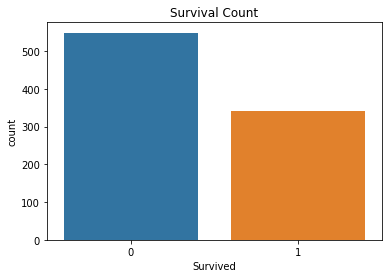

In [12]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

The survival distribution shows that the majority of passengers did not survive (549), while 342 passengers survived. This indicates an imbalanced target variable, where the number of non-survivors is higher than survivors. Such imbalance may influence model performance and should be considered in future modeling steps.

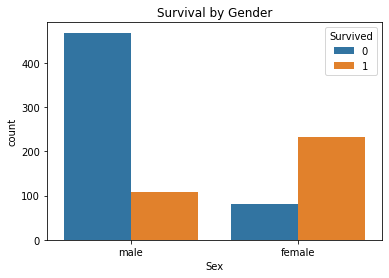

In [13]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

The visualization clearly shows a strong relationship between gender and survival. A significantly higher proportion of females survived compared to males. Most male passengers did not survive, while the majority of female passengers survived. This suggests that gender was a highly influential factor in survival outcomes, possibly due to evacuation priorities.

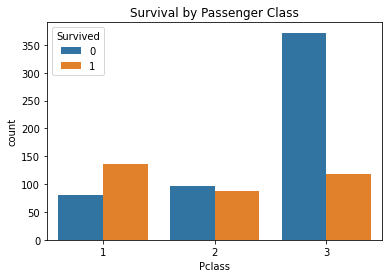

In [14]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

The plot shows a clear relationship between passenger class and survival. Passengers in first class had a significantly higher survival rate compared to those in second and third class. Third-class passengers experienced the highest number of deaths. This suggests that socioeconomic status, reflected by ticket class, played an important role in survival probability.

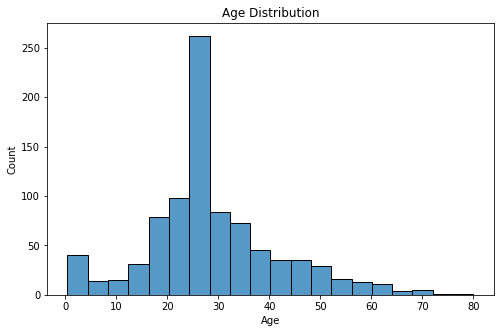

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

The age distribution shows that most passengers were between 20 and 35 years old. There are fewer elderly passengers above 60 years. The distribution appears slightly right-skewed, indicating a longer tail toward older ages. This suggests that the majority of passengers were young adults.

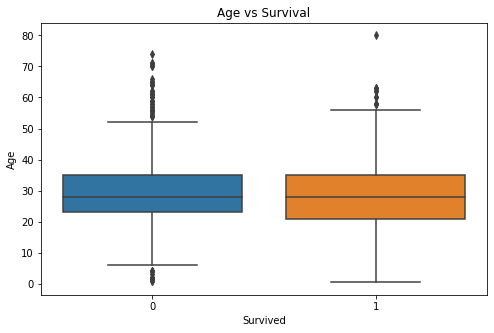

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Age vs Survival")
plt.show()

The boxplot shows that the age distribution between survivors and non-survivors is relatively similar. The median ages are close, and there is no strong difference between the two groups. This suggests that age alone was not a dominant factor in survival, unlike gender or passenger class.

In [17]:
df['Child'] = df['Age'] < 12
df.groupby('Child')['Survived'].mean()

Child
False    0.368165
True     0.573529
Name: Survived, dtype: float64

The results show that children had a significantly higher survival rate (about 57%) compared to non-children (about 36%). This supports the historical "women and children first" evacuation policy, indicating that children were given priority during rescue operations.

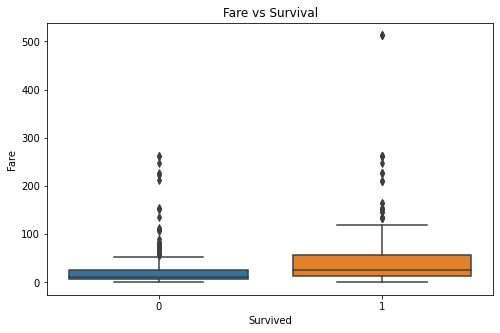

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title("Fare vs Survival")
plt.show()

Passengers who paid higher fares had a higher survival probability, suggesting that wealth and ticket class influenced survival outcomes.

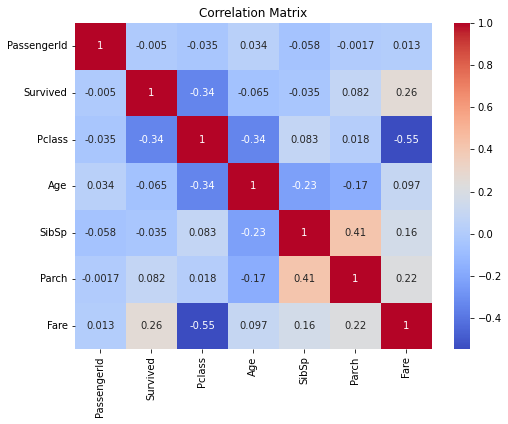

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), 
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows that Pclass has a negative correlation with Fare, meaning higher classes paid higher fares. Survival is moderately related to Pclass and Fare, indicating that socioeconomic status influenced survival probability.

### Conclusion

The exploratory data analysis revealed that gender, passenger class, and fare were strong factors influencing survival. Children also had higher survival rates, supporting historical evacuation priorities. Age alone did not show a strong independent effect. These findings suggest that socioeconomic status and evacuation policies significantly impacted survival outcomes.

# Data Quality & Preprocessing Assignment

**##Task 1**

In [20]:

df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  Child        891 non-null    bool   
dtypes: bool(1), float64(2), int64(5), object(5)
memory usage: 84.5+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Data Quality Issues Identified:

- Missing values detected in Age, Cabin, and Embarked.
- Cabin contains a large number of missing values.
- No duplicate records found.
- Possible outliers observed in Fare feature.

**##Task2**

In [21]:
df["Age"].fillna(df["Age"].mean(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop("Cabin", axis=1, inplace=True)

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Child          0
dtype: int64

**##Task3**

In [22]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]
print("Number of outliers:", len(outliers))

Lower Bound: -26.724
Upper Bound: 65.6344
Number of outliers: 116


In [23]:
df = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]

print("New shape:", df.shape)

New shape: (775, 12)


### Outlier Detection Results:

Using the IQR method, 116 outliers were detected in the Fare feature.
Values above 65.63 were considered extreme and removed to improve data quality.

In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["Age","Fare","SibSp","Parch"]] = scaler.fit_transform(
    df[["Age","Fare","SibSp","Parch"]]
)

df.head()

from sklearn.preprocessing import StandardScaler

scaler_z = StandardScaler()

df_z = scaler_z.fit_transform(
    df[["Age","Fare","SibSp","Parch"]]
)

df_z[:5]

array([[-0.5283213 , -0.77911707,  0.62560563, -0.43371803],
       [-0.21518215, -0.7293725 , -0.48642273, -0.43371803],
       [ 0.48938093,  2.59982835,  0.62560563, -0.43371803],
       [ 0.48938093, -0.72016055, -0.48642273, -0.43371803],
       [-0.05861258, -0.69007062, -0.48642273, -0.43371803]])

### Normalization:

Min-Max normalization scales values between 0 and 1.

Z-score normalization standardizes features to have mean 0 and standard deviation 1.

In [25]:
df[["Age","Fare","SibSp","Parch"]].corr()

,Age,Fare,SibSp,Parch
Age,1.000000,0.085716,-0.335000,-0.204181
Fare,0.085716,1.000000,0.370388,0.336844
SibSp,-0.335000,0.370388,1.000000,0.410182
Parch,-0.204181,0.336844,0.410182,1.000000


### PCA Decision:

Correlation analysis showed no strong relationships between numerical features.
Since all correlation values were below 0.5, PCA was not applied.